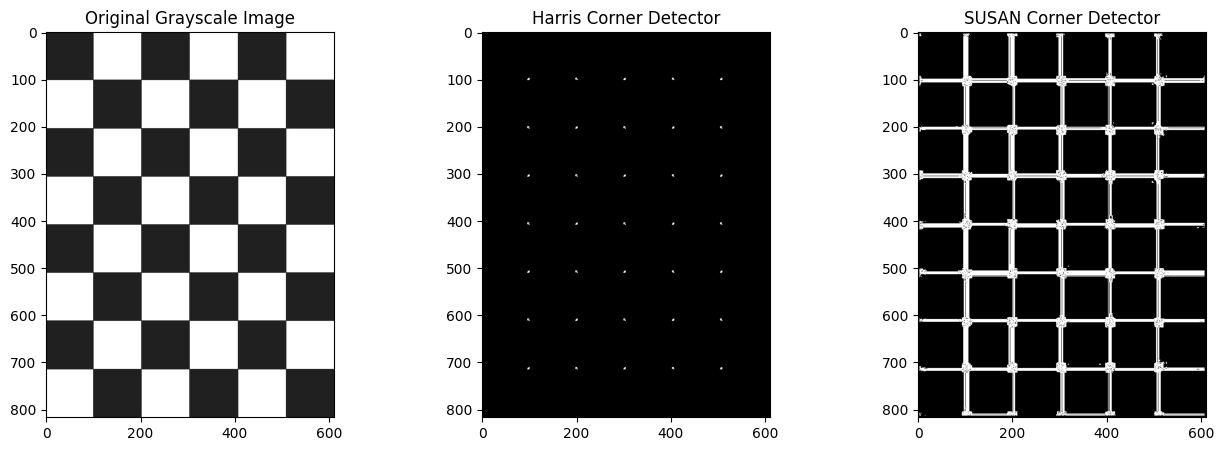

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def load_image(file_path):
    return np.array(Image.open(file_path).convert('L'))

def convolve2d(image, kernel):
    # Flip the kernel
    kernel = np.flipud(np.fliplr(kernel))

    # Get the dimensions of the image and kernel
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Calculate the output dimensions
    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    # Initialize the output image
    output_image = np.zeros((output_height, output_width))

    # Perform 2D convolution
    for i in range(output_height):
        for j in range(output_width):
            output_image[i, j] = np.sum(image[i:i+kernel_height, j:j+kernel_width] * kernel)

    return output_image

def harris_corner_detector(image, k=0.04, threshold=0.01):
    # Compute image gradients
    partial_x = np.array([[-1, 0, 1]])
    partial_y = partial_x.T  # Transpose for vertical kernel

    Ix = convolve2d(image, partial_x)
    Iy = convolve2d(image, partial_y)

    # Ensure that Ix and Iy have the same dimensions
    min_height = min(Ix.shape[0], Iy.shape[0])
    min_width = min(Ix.shape[1], Iy.shape[1])
    Ix = Ix[:min_height, :min_width]
    Iy = Iy[:min_height, :min_width]

    # Compute products of gradients
    Ix2 = Ix**2
    Iy2 = Iy**2
    Ixy = Ix * Iy

    # Compute the sums of products in the windows
    Sx2 = convolve2d(Ix2, np.ones((3, 3)))
    Sy2 = convolve2d(Iy2, np.ones((3, 3)))
    Sxy = convolve2d(Ixy, np.ones((3, 3)))

    # Compute the Harris response
    det = Sx2 * Sy2 - Sxy**2
    trace = Sx2 + Sy2
    harris_response = det - k * trace**2

    # Mark corners above the threshold
    corners = np.zeros_like(image)
    h, w = image.shape
    corners[:min_height-2, :min_width-2][harris_response > threshold * harris_response.max()] = 1

    return corners


def susan_corner_detector(image, radius=3, threshold=0.1):
    susan_response = np.zeros_like(image)

    for i in range(radius, image.shape[0] - radius):
        for j in range(radius, image.shape[1] - radius):
            center_value = image[i, j]
            neighborhood = image[i-radius:i+radius+1, j-radius:j+radius+1]

            # Calculate the response using a power of 6
            response = np.sum((neighborhood - center_value)**6)

            # Thresholding
            if response > threshold:
                susan_response[i, j] = response

    # Normalize the response for visualization
    susan_response = susan_response / susan_response.max()

    # Mark corners above the threshold
    susan_corners = np.zeros_like(image)
    susan_corners[susan_response > threshold ] = 1

    return susan_corners

# Load the image and convert to grayscale
image_path = '/content/drive/MyDrive/RnzgH.jpg'
image = load_image(image_path)

# Apply Harris corner detector
harris_corners = harris_corner_detector(image)

susan_corners = susan_corner_detector(image)
# Display the results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Grayscale Image')

plt.subplot(1, 3, 2)
plt.imshow(harris_corners, cmap='gray')
plt.title('Harris Corner Detector')

plt.subplot(1, 3, 3)
plt.imshow(susan_corners, cmap='gray')
plt.title('SUSAN Corner Detector')

# Explicitly remove overlapping axes
plt.subplots_adjust(wspace=0.5)
plt.show()

